# Water Quality Modeling

## 1. Import Libraries

In [197]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Feature-Engineered Dataset

In [198]:
df = pd.read_csv("/content/ganga_water_quality_features.csv")

df.head()

,location,year,do,bod,fecal_coliform,do_good,bod_good,fecal_good,water_quality_score,year_index,station_id,do_lag1,bod_lag1,fecal_coliform_lag1,do_change,bod_change,fecal_coliform_change
0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2012,7.1,5.1,3450.0,1,0,0,1,1,0,7.2,4.0,3408.0,-0.1,1.1,42.0
1,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2013,8.2,3.6,6475.0,1,0,0,1,2,0,7.1,5.1,3450.0,1.1,-1.5,3025.0
2,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2014,8.6,3.8,26000.0,1,0,0,1,3,0,8.2,3.6,6475.0,0.4,0.2,19525.0
3,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2015,7.9,4.1,21300.0,1,0,0,1,4,0,8.6,3.8,26000.0,-0.7,0.3,-4700.0
4,GANGA AT DAKSHINESHWAR,2012,6.1,4.1,493750.0,1,0,0,1,1,1,7.8,4.0,270333.0,-1.7,0.1,223417.0


In [199]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   location               36 non-null     object 
 1   year                   36 non-null     int64  
 2   do                     36 non-null     float64
 3   bod                    36 non-null     float64
 4   fecal_coliform         36 non-null     float64
 5   do_good                36 non-null     int64  
 6   bod_good               36 non-null     int64  
 7   fecal_good             36 non-null     int64  
 8   water_quality_score    36 non-null     int64  
 9   year_index             36 non-null     int64  
 10  station_id             36 non-null     int64  
 11  do_lag1                36 non-null     float64
 12  bod_lag1               36 non-null     float64
 13  fecal_coliform_lag1    36 non-null     float64
 14  do_change              36 non-null     float64
 15  bod_chan

## 3. Define Target Variable

Dissolved Oxygen (DO) is selected as the first prediction target.

The model will use historical water-quality measurements and station information to predict DO.

## 4. Select Features

In [200]:
features = [
    "year_index",
    "station_id",
    "do_lag1",
    "bod_lag1",
    "fecal_coliform_lag1"]
target = "do"

In [201]:
model_df = df[features + [target]].dropna().copy()

model_df.shape

(36, 6)

In [202]:
model_df.isnull().sum()

,0
year_index,0
station_id,0
do_lag1,0
bod_lag1,0
fecal_coliform_lag1,0
do,0


## 5. Time-Based Train-Test Split

The data is split chronologically to prevent future information from being used during training.

In [203]:
train_df = model_df[model_df["year_index"] < 4].copy()

test_df = model_df[model_df["year_index"] == 4].copy()

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

Training data: (27, 6)
Testing data: (9, 6)


In [204]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [205]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (27, 5)
X_test: (9, 5)


## 6. Linear Regression Baseline

In [206]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

In [207]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R²:", r2_linear)

Linear Regression
MAE: 0.4749661734828999
RMSE: 0.543247419972367
R²: 0.23725148360442594


## 7. Random Forest Regression

In [208]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [209]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest
MAE: 0.5273705467372148
RMSE: 0.6134007435209855
R²: 0.027533559530315443


## 8. Model Comparison

In [210]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2": [
        r2_linear,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.474966,0.543247,0.237251
1,Random Forest,0.527371,0.613401,0.027534


## 9. Actual vs Predicted DO

In [211]:
comparison = pd.DataFrame({
    "Actual_DO": y_test.values,
    "Predicted_DO": y_pred_rf
})

comparison

,Actual_DO,Predicted_DO
0,7.9,8.174220
1,6.6,6.359243
2,7.7,8.939000
3,7.9,7.288095
4,8.4,7.783040
5,6.5,7.308062
6,8.2,7.845824
7,7.5,7.756825
8,7.3,7.644430


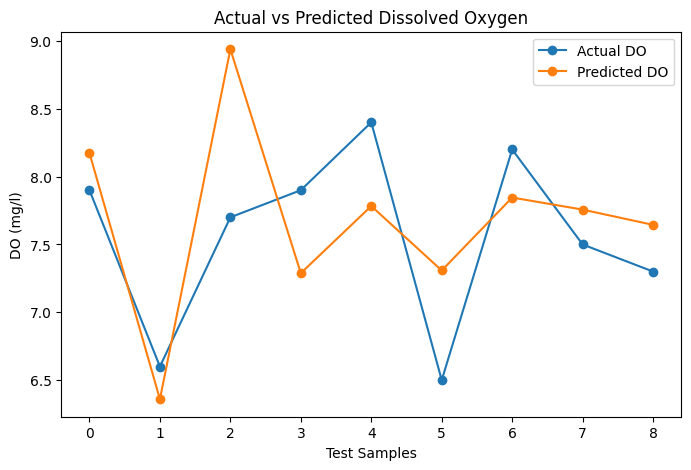

In [212]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    comparison["Actual_DO"].values,
    marker="o",
    label="Actual DO"
)

plt.plot(
    comparison["Predicted_DO"].values,
    marker="o",
    label="Predicted DO"
)

plt.title("Actual vs Predicted Dissolved Oxygen")
plt.xlabel("Test Samples")
plt.ylabel("DO (mg/l)")
plt.legend()

plt.show()

## 10. Feature Importance

In [213]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
4,fecal_coliform_lag1,0.392816
2,do_lag1,0.382817
1,station_id,0.109112
3,bod_lag1,0.080847
0,year_index,0.034407


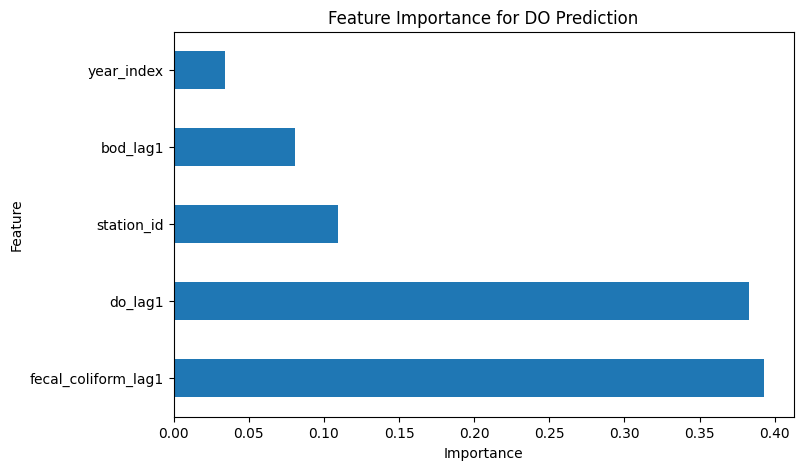

In [214]:
importance.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.title("Feature Importance for DO Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 11. XGBoost Regression

In [215]:
from xgboost import XGBRegressor

In [216]:
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

## 12. XGBoost Evaluation

In [217]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²:", r2_xgb)

XGBoost
MAE: 0.5543669806586371
RMSE: 0.6400147204857376
R²: -0.05868303246692319


## 13. Model Comparison - Traditional ML Models

In [218]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_xgb
    ],
    "R2": [
        r2_linear,
        r2_rf,
        r2_xgb
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.474966,0.543247,0.237251
1,Random Forest,0.527371,0.613401,0.027534
2,XGBoost,0.554367,0.640015,-0.058683


## 14. Actual vs Predicted DO - XGBoost

In [219]:
comparison_xgb = pd.DataFrame({
    "Actual_DO": y_test.values,
    "Predicted_DO": y_pred_xgb
})

comparison_xgb

,Actual_DO,Predicted_DO
0,7.9,8.580278
1,6.6,6.470851
2,7.7,8.966960
3,7.9,7.198463
4,8.4,7.754992
5,6.5,7.086570
6,8.2,7.754992
7,7.5,7.701681
8,7.3,7.633112


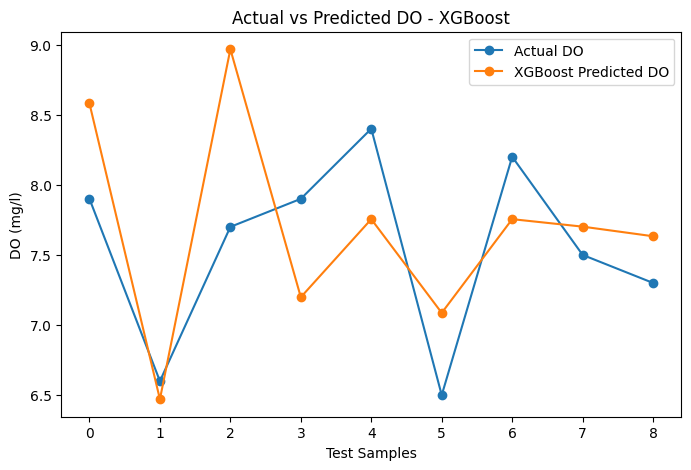

In [220]:
plt.figure(figsize=(8, 5))

plt.plot(
    comparison_xgb["Actual_DO"].values,
    marker="o",
    label="Actual DO"
)

plt.plot(
    comparison_xgb["Predicted_DO"].values,
    marker="o",
    label="XGBoost Predicted DO"
)

plt.title("Actual vs Predicted DO - XGBoost")
plt.xlabel("Test Samples")
plt.ylabel("DO (mg/l)")
plt.legend()

plt.show()

## 15. XGBoost Feature Importance

In [221]:
xgb_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
2,do_lag1,0.401970
3,bod_lag1,0.205880
1,station_id,0.175844
4,fecal_coliform_lag1,0.174673
0,year_index,0.041632


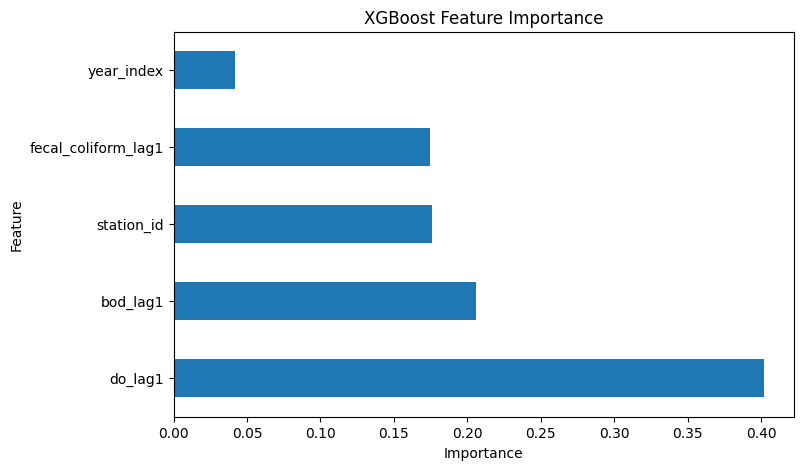

In [222]:
xgb_importance.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 16. Prepare Data for Deep Learning

The data is reshaped into a sequence format suitable for 1D CNN and LSTM models.

In [223]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_test_scaled = scaler_y.transform(
    y_test.values.reshape(-1, 1)
)

In [224]:
X_train_dl = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    X_train_scaled.shape[1],
    1
)

X_test_dl = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

print("Training shape:", X_train_dl.shape)
print("Testing shape:", X_test_dl.shape)

Training shape: (27, 5, 1)
Testing shape: (9, 5, 1)


## 17. 1D CNN Model

A 1D CNN is used to learn local patterns from the input feature sequence.

In [225]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Input

Model:

In [226]:
cnn_model = Sequential([
    Input(shape=(X_train_dl.shape[1], 1)),

    Conv1D(
        filters=32,
        kernel_size=2,
        activation="relu"
    ),

    Flatten(),

    Dense(32, activation="relu"),

    Dense(1)
])

cnn_model.compile(
    optimizer="adam",
    loss="mse"
)

cnn_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 4, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,257 (16.63 KB)

 Trainable params: 4,257 (16.63 KB)

 Non-trainable params: 0 (0.00 B)

Train:

In [227]:
history_cnn = cnn_model.fit(
    X_train_dl,
    y_train_scaled,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

Predict:

In [228]:
y_pred_cnn_scaled = cnn_model.predict(
    X_test_dl
)

y_pred_cnn = scaler_y.inverse_transform(
    y_pred_cnn_scaled
).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


Evaluate:

In [229]:
mae_cnn = mean_absolute_error(
    y_test,
    y_pred_cnn
)

rmse_cnn = np.sqrt(
    mean_squared_error(y_test, y_pred_cnn)
)

r2_cnn = r2_score(
    y_test,
    y_pred_cnn
)

print("1D CNN")
print("MAE:", mae_cnn)
print("RMSE:", rmse_cnn)
print("R²:", r2_cnn)

1D CNN
MAE: 0.8206298934088812
RMSE: 0.9066953396303887
R²: -1.1247546761807508


## 18. LSTM Model

LSTM is used to learn sequential and temporal dependencies in water-quality observations.

In [230]:
from tensorflow.keras.layers import LSTM

In [231]:
lstm_model = Sequential([
    Input(shape=(X_train_dl.shape[1], 1)),

    LSTM(32),

    Dense(16, activation="relu"),

    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

Train:

In [232]:
history_lstm = lstm_model.fit(
    X_train_dl,
    y_train_scaled,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

Predict:

In [233]:
y_pred_lstm_scaled = lstm_model.predict(
    X_test_dl
)

y_pred_lstm = scaler_y.inverse_transform(
    y_pred_lstm_scaled
).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


Evaluate:

In [234]:
mae_lstm = mean_absolute_error(
    y_test,
    y_pred_lstm
)

rmse_lstm = np.sqrt(
    mean_squared_error(y_test, y_pred_lstm)
)

r2_lstm = r2_score(
    y_test,
    y_pred_lstm
)

print("LSTM")
print("MAE:", mae_lstm)
print("RMSE:", rmse_lstm)
print("R²:", r2_lstm)

LSTM
MAE: 0.3920532756381563
RMSE: 0.5293173253340631
R²: 0.27586715689842667


## 19. CNN + LSTM Model

The CNN extracts local patterns while the LSTM learns sequential dependencies.

In [235]:
from tensorflow.keras.layers import MaxPooling1D

In [236]:
cnn_lstm_model = Sequential([
    Input(shape=(X_train_dl.shape[1], 1)),

    Conv1D(
        filters=32,
        kernel_size=2,
        activation="relu"
    ),

    LSTM(32),

    Dense(16, activation="relu"),

    Dense(1)
])

cnn_lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

cnn_lstm_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 4, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,961 (35.00 KB)

 Trainable params: 8,961 (35.00 KB)

 Non-trainable params: 0 (0.00 B)

Train:

In [237]:
history_cnn_lstm = cnn_lstm_model.fit(
    X_train_dl,
    y_train_scaled,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

Predict:

In [238]:
y_pred_cnn_lstm_scaled = cnn_lstm_model.predict(
    X_test_dl
)

y_pred_cnn_lstm = scaler_y.inverse_transform(
    y_pred_cnn_lstm_scaled
).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


Evaluate:

In [239]:
mae_cnn_lstm = mean_absolute_error(
    y_test,
    y_pred_cnn_lstm
)

rmse_cnn_lstm = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_cnn_lstm
    )
)

r2_cnn_lstm = r2_score(
    y_test,
    y_pred_cnn_lstm
)

print("CNN + LSTM")
print("MAE:", mae_cnn_lstm)
print("RMSE:", rmse_cnn_lstm)
print("R²:", r2_cnn_lstm)

CNN + LSTM
MAE: 0.534590000576443
RMSE: 0.6408408419402428
R²: -0.061417860899585675


## 20. Final Model Comparison

In [240]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "1D CNN",
        "LSTM",
        "CNN + LSTM"
    ],

    "MAE": [
        mae_linear,
        mae_rf,
        mae_xgb,
        mae_cnn,
        mae_lstm,
        mae_cnn_lstm
    ],

    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_xgb,
        rmse_cnn,
        rmse_lstm,
        rmse_cnn_lstm
    ],

    "R2": [
        r2_linear,
        r2_rf,
        r2_xgb,
        r2_cnn,
        r2_lstm,
        r2_cnn_lstm
    ]
})

final_results

,Model,MAE,RMSE,R2
0,Linear Regression,0.474966,0.543247,0.237251
1,Random Forest,0.527371,0.613401,0.027534
2,XGBoost,0.554367,0.640015,-0.058683
3,1D CNN,0.820630,0.906695,-1.124755
4,LSTM,0.392053,0.529317,0.275867
5,CNN + LSTM,0.534590,0.640841,-0.061418


## 21. Model Ranking by MAE

In [241]:
final_results.sort_values("MAE")

,Model,MAE,RMSE,R2
4,LSTM,0.392053,0.529317,0.275867
0,Linear Regression,0.474966,0.543247,0.237251
1,Random Forest,0.527371,0.613401,0.027534
5,CNN + LSTM,0.534590,0.640841,-0.061418
2,XGBoost,0.554367,0.640015,-0.058683
3,1D CNN,0.820630,0.906695,-1.124755


## 22. Model Ranking by RMSE

In [242]:
final_results.sort_values("RMSE")

,Model,MAE,RMSE,R2
4,LSTM,0.392053,0.529317,0.275867
0,Linear Regression,0.474966,0.543247,0.237251
1,Random Forest,0.527371,0.613401,0.027534
2,XGBoost,0.554367,0.640015,-0.058683
5,CNN + LSTM,0.534590,0.640841,-0.061418
3,1D CNN,0.820630,0.906695,-1.124755


## 23. Model Ranking by R²

In [243]:
final_results.sort_values(
    "R2",
    ascending=False
)

,Model,MAE,RMSE,R2
4,LSTM,0.392053,0.529317,0.275867
0,Linear Regression,0.474966,0.543247,0.237251
1,Random Forest,0.527371,0.613401,0.027534
2,XGBoost,0.554367,0.640015,-0.058683
5,CNN + LSTM,0.534590,0.640841,-0.061418
3,1D CNN,0.820630,0.906695,-1.124755


## 24. Best Model

In [244]:
best_model = final_results.sort_values(
    "MAE"
).iloc[0]

print("Best Model:", best_model["Model"])
print("MAE:", best_model["MAE"])
print("RMSE:", best_model["RMSE"])
print("R²:", best_model["R2"])

Best Model: LSTM
MAE: 0.3920532756381563
RMSE: 0.5293173253340631
R²: 0.27586715689842667


# 25. Save Best Model

In [245]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

best_model_name = best_model["Model"]

if best_model_name == "Linear Regression":
    joblib.dump(
        linear_model,
        "../models/do_prediction_model.pkl"
    )

elif best_model_name == "Random Forest":
    joblib.dump(
        rf_model,
        "../models/do_prediction_model.pkl"
    )

elif best_model_name == "XGBoost":
    joblib.dump(
        xgb_model,
        "../models/do_prediction_model.pkl"
    )

elif best_model_name == "1D CNN":
    cnn_model.save(
        "../models/do_prediction_model.keras"
    )

elif best_model_name == "LSTM":

    lstm_model.save(
        "../models/do_prediction_model.keras"
    )

    joblib.dump(
        scaler_X,
        "../models/scaler_X.pkl"
    )

    joblib.dump(
        scaler_y,
        "../models/scaler_y.pkl"
    )

elif best_model_name == "CNN + LSTM":
    cnn_lstm_model.save(
        "../models/do_prediction_model.keras"
    )

print("Best model saved:", best_model_name)

Best model saved: LSTM


## 26. Final Model Performance Comparison

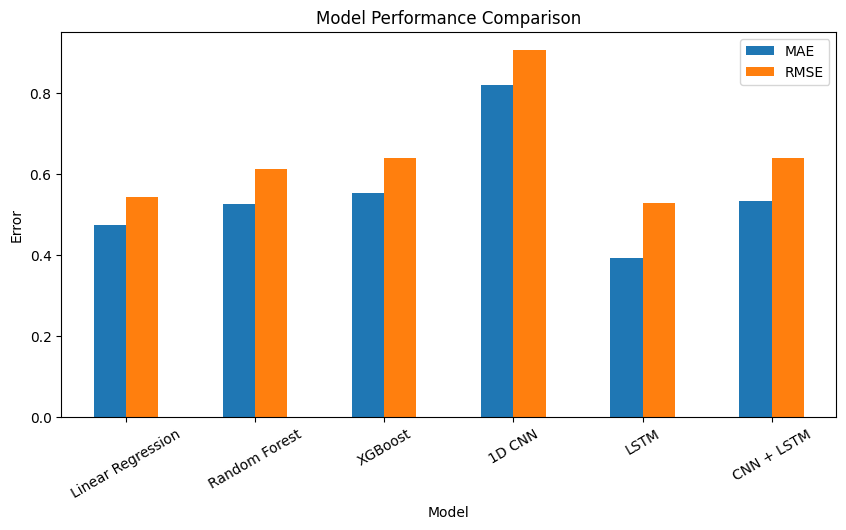

In [246]:
final_results.plot(
    x="Model",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(rotation=30)
plt.show()

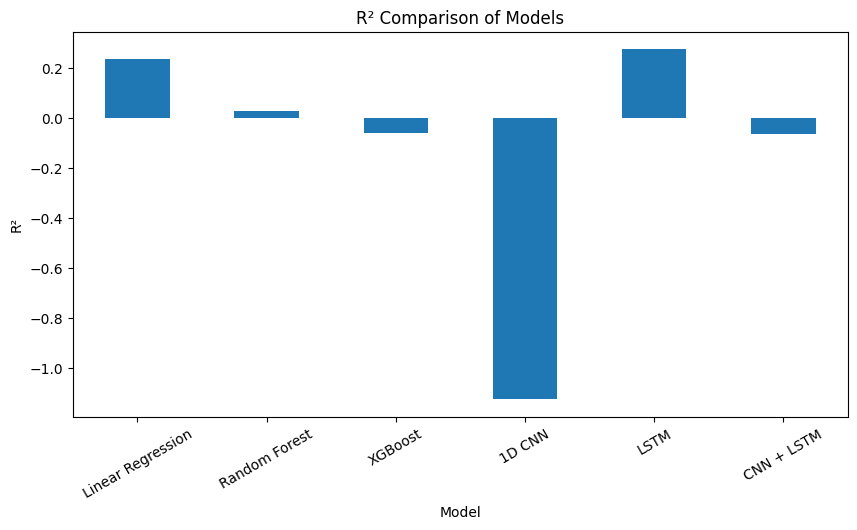

In [247]:
final_results.plot(
    x="Model",
    y="R2",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("R² Comparison of Models")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=30)
plt.show()

## 27. Modeling Findings

Six models were evaluated for Dissolved Oxygen (DO) prediction:

- Linear Regression
- Random Forest
- XGBoost
- 1D CNN
- LSTM
- CNN + LSTM

The models were evaluated using MAE, RMSE, and R².

Lower MAE and RMSE indicate better prediction performance, while higher R² indicates better performance.

The best-performing model was selected based on the overall evaluation results.

The current dataset contains 50 observations from 10 stations over 5 years. Therefore, deep learning results should be interpreted cautiously. A larger time-series dataset would be required for more reliable CNN and LSTM forecasting.

### Conclusion

The modeling results provide a baseline for Dissolved Oxygen prediction in the Ganga River.

The model comparison helps identify the most suitable approach for the available dataset. The selected model will be used in the next stage for future water-quality forecasting.

The forecasting results will then be used to support the early-warning component of the Aquanga system.

In [248]:
from google.colab import files

files.download("../models/do_prediction_model.keras")
files.download("../models/scaler_X.pkl")
files.download("../models/scaler_y.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>